# 45 — Colorado sportsbook source and metric research walkthrough

## 1. Research question, scope, alternatives, and limitations

**Research question.** What Colorado official sportsbook data is available, at what granularity, and how should its native metrics map to the existing `gaming_results` data model?

**Scope.** Methodology research and a notebook prototype only. Official Colorado Department of Revenue / Division of Gaming (Specialized Business Group) monthly Sports Betting Proceeds PDFs and the related HB 21-1292 city reports. Six sampled monthly PDFs spanning at least two years, including the latest available completed reporting month.

**This notebook does not:**
- build or register a production collector
- mutate shared metric-contract code, schema, tests, or dependencies
- invent online figures from combined totals
- invent operator brands from statewide reports
- create a substitute SQLite database or claim a database comparison (the production DB is intentionally unavailable here)
- download the entire historical archive

**Alternatives considered.**
1. Treat Net Sports Betting Proceeds (NSBP) as interchangeable with GGR — **rejected**; statute and the PDF footnotes define them separately.
2. Collect only the HB 21-1292 city NSBP/tax pages — **rejected as primary**; those pages omit handle, payouts, and GGR.
3. Proposed path — inventory the monthly Proceeds PDFs, preserve GGR and NSBP as separate native measures, map channels explicitly, and recommend eligibility without changing the shared contract.

**Limitations (stated up front).**
- Sample of six months cannot prove full-history parser readiness.
- Some archive months are non-text PDFs (require OCR); OCR can misread glyphs.
- May 2020 / June 2020 landing links returned HTTP 404 during this research.
- Publication/revision clocks on the landing page are often unlabeled; unknown timestamps remain unknown.
- Inventory CSV says “operator and statewide”; the public monthly PDFs inspected here do **not** expose operator brands.


## 2. Reproducible setup (no database)

**What.** Locate the repo root, record Python/package versions and Git HEAD, ensure `data/raw/CO/` exists, and confirm the production SQLite file is absent.

**Why.** This walkthrough must stay read-only with respect to shared modules and must not fabricate a stand-in database.

**Assumptions.** Official HTTPS endpoints remain reachable with ordinary TLS verification. Retained raw bytes under `data/raw/CO/` are immutable hashed captures.

**Inspect.** Root path, versions, HEAD, raw directory, and the explicit statement that `data/gaming.sqlite` is unavailable.


In [1]:
from __future__ import annotations

import hashlib
import re
import subprocess
import sys
import tempfile
from decimal import Decimal, ROUND_HALF_EVEN
from pathlib import Path
from urllib.parse import unquote, urlparse

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import pdfplumber
from bs4 import BeautifulSoup
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import (
    http_get,
    http_get_unchecked,
    month_period,
    parse_money,
    project_root,
    save_raw_bytes,
    sha256_bytes,
    utc_now,
)

ROOT = project_root()
RAW_CO = ROOT / "data" / "raw" / "CO"
RAW_CO.mkdir(parents=True, exist_ok=True)
DATABASE_PATH = ROOT / "data" / "gaming.sqlite"

BROWSER_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    )
}

LANDING_URL = "https://sbg.colorado.gov/sports-betting-monthly-reports"
STATUTE_NSBP = (
    "C.R.S. 44-30-1501(7) / 1 CCR 207-2-1.4(13): net sports betting proceeds "
    "= bets placed excluding free bets, less payments to players, less federal excise taxes."
)

# Optional download step. When True, fetch sample PDFs and reuse identical retained bytes.
DOWNLOAD_ENABLED = True

# Tolerances fixed a priori from source precision (printed dollars-and-cents).
# Comparisons use Decimal cent quantization so float binary noise is not mistaken
# for a tolerance change. Do not silently widen after failures.
MONEY_TOL_NATIVE = Decimal("0.01")
MONEY_TOL_OCR = Decimal("0.02")  # fixed a-priori OCR jitter allowance
PCT_TOL = 0.05  # win% diagnostic only


def as_cents(value) -> Decimal:
    return Decimal(str(value)).quantize(Decimal("0.01"), rounding=ROUND_HALF_EVEN)


def money_close(actual, expected, tol: Decimal) -> bool:
    if actual is None or expected is None or pd.isna(actual) or pd.isna(expected):
        return False
    return abs(as_cents(actual) - as_cents(expected)) <= tol


def git_head() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return "unavailable"


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


print("Repository root:", ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("pdfplumber:", pdfplumber.__version__)
print("Git HEAD:", git_head())
print("Raw CO directory:", RAW_CO)
print("Existing retained CO files:", len(list(RAW_CO.rglob("*.pdf"))))
print("Production SQLite present:", DATABASE_PATH.exists())
if DATABASE_PATH.exists():
    raise RuntimeError(
        "Unexpected local gaming.sqlite — this research notebook must not use or replace it."
    )
print("Database status: intentionally unavailable (no substitute created).")


Repository root: /workspace
Python: 3.11.16
pandas: 3.0.5
pdfplumber: 0.11.10
Git HEAD: 4074f969b2fd46f30a5584a18ab09acd5b0c0119
Raw CO directory: /workspace/data/raw/CO
Existing retained CO files: 13
Production SQLite present: False
Database status: intentionally unavailable (no substitute created).


## 3. Official source inventory and historical coverage

**What.** Fetch the Division of Gaming monthly-reports landing page, list main Proceeds PDFs versus HB 21-1292 city PDFs, and summarize revision labels without downloading every file.

**Why.** Coverage and layout regime must be known before proposing a collector.

**Assumptions.** The landing page HTML is the authoritative public archive index for this research. Link-text revision notes are incomplete; filename tokens like `v2` / `Revised` are additional signals only.

**Inspect.** Counts by series, earliest/latest labels, 404 probes for launch months, and later text-extractability notes from the sampled set.


In [2]:
landing_retrieved_at = utc_now()
landing_response = http_get(LANDING_URL, headers=BROWSER_HEADERS)
landing_html = landing_response.text
landing_sha = sha256_bytes(landing_response.content)
landing_path = save_raw_bytes(
    ROOT,
    "CO",
    landing_response.content,
    "sports_betting_monthly_reports_landing.html",
    retrieved_at=landing_retrieved_at,
)

soup = BeautifulSoup(landing_html, "html.parser")
rows = []
for anchor in soup.find_all("a", href=True):
    label = " ".join(anchor.get_text(" ", strip=True).split())
    href = anchor["href"]
    if not href:
        continue
    if href.startswith("/"):
        href = "https://sbg.colorado.gov" + href
    elif href.startswith("sites/"):
        href = "https://sbg.colorado.gov/" + href
    low = label.lower()
    if not href.lower().endswith(".pdf"):
        continue
    if "hb" in low and "1292" in low:
        series = "hb21_1292_city"
    elif "sports betting" in low and "proceeds" in low:
        series = "monthly_proceeds"
    else:
        series = "other_pdf"
    rows.append(
        {
            "series": series,
            "label": label,
            "url": href,
            "label_mentions_revision": bool(re.search(r"revis|correct", label, flags=re.I)),
            "filename_mentions_revision": bool(
                re.search(r"revis|correct|_v\d|v\.\d", unquote(href), flags=re.I)
            ),
        }
    )

inventory = pd.DataFrame(rows).drop_duplicates(subset=["url", "label"])
display(inventory.groupby("series", dropna=False).size().rename("pdf_links").to_frame())

monthly = inventory.loc[inventory["series"] == "monthly_proceeds"].copy()
display(monthly[["label", "url"]].head(8))
display(monthly[["label", "url"]].tail(8))

print("Landing URL:", LANDING_URL)
print(
    "Landing retrieved_at_utc:",
    landing_retrieved_at.isoformat().replace("+00:00", "Z"),
)
print("Landing relative path:", landing_path.relative_to(ROOT))
print("Landing SHA-256:", landing_sha)
print("Monthly proceeds links:", len(monthly))
print("HB 21-1292 links:", int((inventory["series"] == "hb21_1292_city").sum()))
print("Label-revision flags (monthly):", int(monthly["label_mentions_revision"].sum()))
print(
    "Filename-revision flags (monthly):",
    int(monthly["filename_mentions_revision"].sum()),
)

for probe_label in [
    "May 2020 Sports Betting Proceeds Report",
    "June 2020 Sports Betting Proceeds Report",
]:
    match = inventory.loc[inventory["label"] == probe_label]
    if match.empty:
        print(probe_label, "-> not listed on landing page")
        continue
    probe_url = match.iloc[0]["url"]
    probe = http_get_unchecked(probe_url, headers=BROWSER_HEADERS)
    print(
        probe_label,
        "-> HTTP",
        probe.status_code,
        "content-type",
        probe.headers.get("content-type"),
        "pdf_magic",
        probe.content[:4] == b"%PDF",
    )


,pdf_links
series,
hb21_1292_city,62
monthly_proceeds,76
other_pdf,1


,label,url
0,July 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
1,June 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
2,May 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
3,April 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
4,March 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
5,February 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
6,January 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...
7,December 2025 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/docum...


,label,url
69,December 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/08%20...
70,November 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/07%20...
71,October 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/06%20...
72,September 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/05%20...
73,August 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/04%20...
74,July 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/03%20...
75,June 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/02%20...
76,May 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/01%20...


Landing URL: https://sbg.colorado.gov/sports-betting-monthly-reports
Landing retrieved_at_utc: 2026-09-05T00:18:01.126383Z
Landing relative path: data/raw/CO/2026-09-05/2fbcc3618ce2b9c617c94f07573eb2335f9ece4a97078fbb64bb626c25a4f355_sports_betting_monthly_reports_landing.html
Landing SHA-256: 2fbcc3618ce2b9c617c94f07573eb2335f9ece4a97078fbb64bb626c25a4f355
Monthly proceeds links: 76
HB 21-1292 links: 62
Label-revision flags (monthly): 1
Filename-revision flags (monthly): 21
May 2020 Sports Betting Proceeds Report -> HTTP 404 content-type text/html; charset=UTF-8 pdf_magic False


June 2020 Sports Betting Proceeds Report -> HTTP 404 content-type text/html; charset=UTF-8 pdf_magic False


## 4. Definitions (independently verified)

**What.** Record statutory / regulatory definitions beside the PDF footnote language.

**Why.** Gross Gaming Revenue and Net Sports Betting Proceeds are not interchangeable. Mapping into `gross_revenue` versus `net_proceeds` depends on these definitions.

**Assumptions.** PDF footnotes define GGR for the monthly Proceeds report. NSBP follows C.R.S. / 1 CCR 207-2. Tax rate is statutory 10% of NSBP at the licensee calculation stage; statewide aggregates can diverge from 10% when operator-level floors/true-ups exist.

**Inspect.** The definition table and the explicit non-equivalence warning.


In [3]:
definition_rows = pd.DataFrame(
    [
        {
            "native_term": "Gross Wagers / Total Wagers (handle)",
            "published_definition": (
                "Sum of amounts wagered in the reporting month, shown by sport and by "
                "Retail / Online / Total in the Top 10 Sports table."
            ),
            "source": "Monthly Sports Betting Proceeds PDF sport table",
        },
        {
            "native_term": "Payments to Players (payouts)",
            "published_definition": (
                "Amounts paid to players on winning wagers; paired with Total Wagers by sport."
            ),
            "source": "Monthly Sports Betting Proceeds PDF sport table",
        },
        {
            "native_term": "Gross Gaming Revenue (GGR)",
            "published_definition": "Gross Wagers - Payments to Players",
            "source": "PDF footnote on every sampled Proceeds report",
        },
        {
            "native_term": "Free bets / promotional bets",
            "published_definition": (
                "Non-cashable vouchers, coupons, electronic credits or promotions "
                "(1 CCR 207-2-1.4(9)). Excluded when computing NSBP; not printed as a "
                "standalone statewide column on the Proceeds summary."
            ),
            "source": "1 CCR 207-2-1.4(9); implied by NSBP statute",
        },
        {
            "native_term": "Net Sports Betting Proceeds (NSBP)",
            "published_definition": (
                "Total bets placed excluding free bets, less payments to players, "
                "less federal excise taxes paid under federal law."
            ),
            "source": STATUTE_NSBP
            + "; PDF footnote labels NSBP without expanding the formula",
        },
        {
            "native_term": "Sports betting tax",
            "published_definition": (
                "10% of net sports betting proceeds (C.R.S. 44-30-1508). Remitted monthly."
            ),
            "source": "C.R.S. 44-30-1508; 1 CCR 207-2-4",
        },
        {
            "native_term": "Total Win Percentage",
            "published_definition": (
                "Printed retail/online/total percentage on the summary; empirically tracks "
                "GGR / handle when both are available."
            ),
            "source": "Monthly Proceeds PDF summary row",
        },
    ]
)
display(definition_rows)

print("HARD RULE: do not relabel NSBP as GGR, and do not store NSBP into gross_revenue.")
print(
    "HARD RULE: test handle - payouts against reported GGR only when channel and period align."
)


,native_term,published_definition,source
0,Gross Wagers / Total Wagers (handle),"Sum of amounts wagered in the reporting month,...",Monthly Sports Betting Proceeds PDF sport table
1,Payments to Players (payouts),Amounts paid to players on winning wagers; pai...,Monthly Sports Betting Proceeds PDF sport table
2,Gross Gaming Revenue (GGR),Gross Wagers - Payments to Players,PDF footnote on every sampled Proceeds report
3,Free bets / promotional bets,"Non-cashable vouchers, coupons, electronic cre...",1 CCR 207-2-1.4(9); implied by NSBP statute
4,Net Sports Betting Proceeds (NSBP),"Total bets placed excluding free bets, less pa...",C.R.S. 44-30-1501(7) / 1 CCR 207-2-1.4(13): ne...
5,Sports betting tax,10% of net sports betting proceeds (C.R.S. 44-...,C.R.S. 44-30-1508; 1 CCR 207-2-4
6,Total Win Percentage,Printed retail/online/total percentage on the ...,Monthly Proceeds PDF summary row


HARD RULE: do not relabel NSBP as GGR, and do not store NSBP into gross_revenue.
HARD RULE: test handle - payouts against reported GGR only when channel and period align.


## 5. Select six monthly reports and optional download

**What.** Choose six main-series monthly Proceeds PDFs spanning September 2020 through July 2026, including the latest completed month and both text-extractable and OCR-needed layouts. Download only when `DOWNLOAD_ENABLED` is true; reuse identical retained hashed files via `save_raw_bytes`. Never overwrite different bytes at the same path.

**Why.** A bounded sample exposes metric mapping, channel structure, and layout regimes without archiving everything.

**Sample design.**

| period | why included |
| --- | --- |
| 2026-07 | latest available completed month (text layer) |
| 2025-12 | recent month inside the non-text/OCR regime |
| 2024-06 | revised (`v2`) OCR-regime layout |
| 2023-12 | revised OCR-regime layout |
| 2022-09 | text layout near the apparent text→image transition |
| 2020-09 | early revised text layout (May/June 2020 links 404) |

**Inspect.** Exact URLs, UTC retrieval timestamps, relative paths, SHA-256 hashes, page counts, and whether a native text layer exists.


In [4]:
SAMPLE_SPEC = [
    {
        "period": "2026-07",
        "label": "July 2026 Sports Betting Proceeds Report",
        "layout_expectation": "native_text",
        "role": "latest_completed_month",
    },
    {
        "period": "2025-12",
        "label": "December 2025 Sports Betting Proceeds Report",
        "layout_expectation": "ocr_needed",
        "role": "recent_image_regime",
    },
    {
        "period": "2024-06",
        "label": "June 2024 Sports Betting Proceeds Report",
        "layout_expectation": "ocr_needed",
        "role": "revised_image_regime",
    },
    {
        "period": "2023-12",
        "label": "December 2023 Sports betting Proceeds Report",
        "layout_expectation": "ocr_needed",
        "role": "revised_image_regime",
    },
    {
        "period": "2022-09",
        "label": "September 2022 Sports Betting Proceeds Report",
        "layout_expectation": "native_text",
        "role": "text_near_transition",
    },
    {
        "period": "2020-09",
        "label": "September 2020 Sports Betting Proceeds Report",
        "layout_expectation": "native_text",
        "role": "early_revised_text",
    },
]

label_to_url = {row["label"]: row["url"] for _, row in monthly.iterrows()}

manifest_rows = []
for spec in SAMPLE_SPEC:
    label = spec["label"]
    if label not in label_to_url:
        raise RuntimeError(f"Sample label missing from landing inventory: {label}")
    url = label_to_url[label]
    retrieved_at = utc_now()
    if not DOWNLOAD_ENABLED:
        raise RuntimeError(
            "DOWNLOAD_ENABLED is False; enable it or provide retained files explicitly."
        )
    response = http_get(url, headers=BROWSER_HEADERS)
    if response.content[:4] != b"%PDF":
        raise RuntimeError(f"Not a PDF for {label}: {url}")
    filename = Path(unquote(urlparse(url).path)).name
    path = save_raw_bytes(
        ROOT, "CO", response.content, filename, retrieved_at=retrieved_at
    )
    digest = sha256_file(path)
    with pdfplumber.open(path) as pdf:
        n_pages = len(pdf.pages)
        n_chars = len(pdf.pages[0].chars or [])
        native_text = bool((pdf.pages[0].extract_text() or "").strip())
    period_start, period_end = month_period(
        int(spec["period"][:4]), int(spec["period"][5:7])
    )
    manifest_rows.append(
        {
            **spec,
            "url": url,
            "retrieved_at_utc": retrieved_at.isoformat().replace("+00:00", "Z"),
            "relative_path": str(path.relative_to(ROOT)),
            "source_sha256": digest,
            "bytes": path.stat().st_size,
            "pages": n_pages,
            "page1_chars": n_chars,
            "native_text_layer": native_text,
            "report_period_start": period_start,
            "report_period_end": period_end,
            "publication_timestamp": None,
        }
    )

manifest = pd.DataFrame(manifest_rows)
display(
    manifest[
        [
            "period",
            "role",
            "layout_expectation",
            "native_text_layer",
            "pages",
            "bytes",
            "source_sha256",
            "relative_path",
            "url",
            "retrieved_at_utc",
            "publication_timestamp",
        ]
    ]
)

assert len(manifest) == 6
assert manifest["period"].nunique() == 6
span_years = (
    pd.to_datetime(manifest["report_period_end"]).max().year
    - pd.to_datetime(manifest["report_period_start"]).min().year
)
print("Sample year span (end.year - start.year):", span_years)
assert span_years >= 2
print("Latest sampled period:", manifest["period"].iloc[0])
print(
    "Clocks distinguished: report_period_* = activity month; "
    "retrieved_at_utc = download clock; publication_timestamp = unknown."
)


,period,role,layout_expectation,native_text_layer,pages,bytes,source_sha256,relative_path,url,retrieved_at_utc,publication_timestamp
0,2026-07,latest_completed_month,native_text,True,2,118528,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,https://sbg.colorado.gov/sites/sbg/files/docum...,2026-09-05T00:18:01.336728Z,None
1,2025-12,recent_image_regime,ocr_needed,False,2,500474,a3405fef6f01099849af27df7454035999b77926e899e7...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,https://sbg.colorado.gov/sites/sbg/files/docum...,2026-09-05T00:18:01.461807Z,None
2,2024-06,revised_image_regime,ocr_needed,False,1,548853,237ecb59053d1b3a2f28db19a0e309dc332335071d46c5...,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db1...,https://sbg.colorado.gov/sites/sbg/files/docum...,2026-09-05T00:18:03.726617Z,None
3,2023-12,revised_image_regime,ocr_needed,False,1,570854,34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9...,data/raw/CO/2026-09-05/34df10fe7b297f5a9a0b38c...,https://sbg.colorado.gov/sites/sbg/files/docum...,2026-09-05T00:18:06.178867Z,None
4,2022-09,text_near_transition,native_text,True,2,102781,fc49c0d9f2b7e09442a71c1d83ecb4582279a6ff5f5a7b...,data/raw/CO/2026-09-05/fc49c0d9f2b7e09442a71c1...,https://sbg.colorado.gov/sites/sbg/files/docum...,2026-09-05T00:18:08.436336Z,None
5,2020-09,early_revised_text,native_text,True,2,204510,adb632d2fee1246832c7abac1428480be6ff951aa73471...,data/raw/CO/2026-09-05/adb632d2fee1246832c7aba...,https://sbg.colorado.gov/sites/sbg/files/05%20...,2026-09-05T00:18:08.572480Z,None


Sample year span (end.year - start.year): 6
Latest sampled period: 2026-07
Clocks distinguished: report_period_* = activity month; retrieved_at_utc = download clock; publication_timestamp = unknown.


## 6. Raw tables: shape, columns, types, representative rows, units

**What.** Extract page text (native or OCR), show representative raw lines, and parse the statewide summary plus the sport wager/payout total row.

**Why.** Transformations must stay explicit. Analysts should see units ($) and the Retail / Online / Total column geometry before any normalization.

**Assumptions.**
- Native text is preferred; OCR (`pdftoppm` + `tesseract`) is used only when page-1 has no text layer.
- Some native extractions wrap positive GGR/NSBP in parentheses; channel-additivity against the Total column is used to detect false parentheses. True leading minus signs (for example September 2020 NSBP) are preserved.
- Sport-table `Total` rows provide handle and payouts; they are monthly activity, not YTD.

**Inspect.** Raw text previews, parsed summary values, and unit notes.


In [5]:
def ocr_pdf(path: Path, dpi: int = 250) -> str:
    with tempfile.TemporaryDirectory() as tmp:
        prefix = Path(tmp) / "page"
        subprocess.check_call(["pdftoppm", "-png", "-r", str(dpi), str(path), str(prefix)])
        chunks: list[str] = []
        for image in sorted(Path(tmp).glob("page*.png")):
            chunks.append(
                subprocess.check_output(
                    ["tesseract", str(image), "stdout", "--psm", "6"],
                    text=True,
                )
            )
        return "\n".join(chunks)


def extract_report_text(path: Path) -> tuple[str, str]:
    with pdfplumber.open(path) as pdf:
        native = "\n".join((page.extract_text() or "") for page in pdf.pages).strip()
    if native:
        return native, "native_text"
    return ocr_pdf(path), "ocr_tesseract"


MONEY_TOKEN = (
    r"\(\$\s*[\d,]+\.\d{2}\)|"
    r"-\$\s*[\d,]+\.\d{2}|"
    r"\$\s*-[\d,]+\.\d{2}|"
    r"-[\d,]+\.\d{2}|"
    r"\$\s*[\d,]+\.\d{2}|"
    r"[\d,]+\.\d{2}"
)


def parse_money_token(token: str) -> float | None:
    return parse_money(token)


def repair_false_parentheses(values: list[float]) -> list[float]:
    # If three channel values look like (|r|+|o|=|t|) but signs disagree with
    # additivity, drop false parentheses and keep the total's sign.
    if len(values) != 3:
        return values
    retail, online, total = values
    abs_sum_ok = money_close(abs(retail) + abs(online), abs(total), MONEY_TOL_OCR)
    signed_sum_ok = money_close(retail + online, total, MONEY_TOL_OCR)
    if abs_sum_ok and not signed_sum_ok:
        sign = 1.0 if total >= 0 else -1.0
        return [sign * abs(retail), sign * abs(online), total]
    return values


def find_summary_amounts(text: str, label_regex: str) -> list[float] | None:
    for line in text.splitlines():
        if re.search(label_regex, line, flags=re.I):
            tokens = re.findall(MONEY_TOKEN, line)
            values = [parse_money_token(tok) for tok in tokens]
            values = [v for v in values if v is not None]
            if len(values) >= 3:
                return repair_false_parentheses(values[:3])
    return None


def find_win_pct(text: str) -> list[float] | None:
    for line in text.splitlines():
        if re.search(r"Total\s+Win\s+Percentage", line, flags=re.I):
            pcts = [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?", line)]
            # Typical line has exactly 3 percentages; keep the last 3 if more appear.
            if len(pcts) >= 3:
                return pcts[-3:]
    return None


def find_wager_payout_total(text: str) -> list[float] | None:
    # Return [retail_w, online_w, total_w, retail_p, online_p, total_p].
    candidates: list[list[float]] = []
    for line in text.splitlines():
        stripped = line.strip()
        if not re.match(r"Total[\s|]", stripped):
            continue
        if "GGR" in stripped or "NSBP" in stripped or "Taxes" in stripped:
            continue
        if "Win Percentage" in stripped:
            continue
        tokens = re.findall(MONEY_TOKEN, stripped)
        values = [parse_money_token(tok) for tok in tokens]
        values = [v for v in values if v is not None]
        if len(values) >= 6:
            candidates.append(values[:6])
    return candidates[-1] if candidates else None


raw_previews = []
parsed_summaries = []
for row in manifest.itertuples(index=False):
    path = ROOT / row.relative_path
    text, extract_method = extract_report_text(path)
    ggr = find_summary_amounts(text, r"Total\s+GGR")
    nsbp = find_summary_amounts(text, r"Total\s+NSBP")
    taxes = find_summary_amounts(text, r"Total\s+Taxes")
    win_pct = find_win_pct(text)
    wager_pay = find_wager_payout_total(text)
    month = re.search(
        r"(January|February|March|April|May|June|July|August|September|October|November|December)\s+(\d{4})",
        text,
    )
    parsed_summaries.append(
        {
            "period": row.period,
            "extract_method": extract_method,
            "header_month": f"{month.group(1)} {month.group(2)}" if month else None,
            "ggr_retail": None if not ggr else ggr[0],
            "ggr_online": None if not ggr else ggr[1],
            "ggr_total": None if not ggr else ggr[2],
            "nsbp_retail": None if not nsbp else nsbp[0],
            "nsbp_online": None if not nsbp else nsbp[1],
            "nsbp_total": None if not nsbp else nsbp[2],
            "tax_retail": None if not taxes else taxes[0],
            "tax_online": None if not taxes else taxes[1],
            "tax_total": None if not taxes else taxes[2],
            "win_pct_retail": None if not win_pct else win_pct[0],
            "win_pct_online": None if not win_pct else win_pct[1],
            "win_pct_total": None if not win_pct else win_pct[2],
            "handle_retail": None if not wager_pay else wager_pay[0],
            "handle_online": None if not wager_pay else wager_pay[1],
            "handle_total": None if not wager_pay else wager_pay[2],
            "payouts_retail": None if not wager_pay else wager_pay[3],
            "payouts_online": None if not wager_pay else wager_pay[4],
            "payouts_total": None if not wager_pay else wager_pay[5],
            "units": "USD dollars-and-cents as printed",
            "table_grain_notes": (
                "Statewide summary is monthly Retail/Online/Total. "
                "Sport table is monthly by sport; Total row is monthly, not YTD. "
                "No fiscal-year or cumulative table is used from these PDFs."
            ),
        }
    )
    raw_previews.append(
        {
            "period": row.period,
            "extract_method": extract_method,
            "preview": "\n".join(text.splitlines()[:18]),
        }
    )

summary = pd.DataFrame(parsed_summaries)
preview_df = pd.DataFrame(raw_previews)
display(preview_df)
display(summary.T)


,period,extract_method,preview
0,2026-07,native_text,Colorado Sports Betting Proceeds\nJuly 2026\nS...
1,2025-12,ocr_tesseract,Colorado Sports Betting Proceeds\nDecember 202...
2,2024-06,ocr_tesseract,Colorado Sports Betting Proceeds*\nJune 2024\n...
3,2023-12,ocr_tesseract,Colorado Sports Betting Proceeds\nDecember 202...
4,2022-09,native_text,Colorado Sports Be ng Proceeds\nSeptember 2022...
5,2020-09,native_text,Colorado Sports Betting Proceeds *\nSeptember ...


,0,1,2,3,4,5
period,2026-07,2025-12,2024-06,2023-12,2022-09,2020-09
extract_method,native_text,ocr_tesseract,ocr_tesseract,ocr_tesseract,native_text,native_text
header_month,July 2026,December 2025,June 2024,December 2023,September 2022,September 2020
ggr_retail,40200.5,554602.32,111199.09,63546.25,659647.3,403259.3
ggr_online,46692707.94,59028627.07,28085098.16,40473952.89,50680011.95,3763074.91
ggr_total,46732908.44,59583229.39,28196297.25,40537499.14,51339659.25,4166334.21
nsbp_retail,36842.91,545781.19,107341.67,52384.1,648461.3,394156.59
nsbp_online,45502869.94,46139809.76,19064299.47,25015648.76,31022372.96,-3788347.03
nsbp_total,45539712.85,46685590.94,19171641.15,25068032.86,31670834.25,-3394190.44
tax_retail,9199.39,12670.67,7130.36,7949.31,39584.96,39415.67


## 7. Explicit extraction of monthly observations

**What.** Melt the parsed statewide summary into one row per period × channel with native measures kept separate.

**Why.** The storage model is period-based. Channels must not be collapsed before mapping.

**Assumptions.** `Total` is an official combined statewide control total, not a substitute for missing online detail. Operator-level rows are unavailable in these PDFs.

**Inspect.** Long monthly observation table.


In [6]:
channel_frames = []
for row in summary.itertuples(index=False):
    meta = manifest.loc[manifest["period"] == row.period].iloc[0]
    for channel, suffix in [("retail", "retail"), ("online", "online"), ("combined", "total")]:
        channel_frames.append(
            {
                "period": row.period,
                "period_start": meta["report_period_start"],
                "period_end": meta["report_period_end"],
                "channel": channel,
                "frequency": "monthly",
                "handle": getattr(row, f"handle_{suffix}"),
                "payouts": getattr(row, f"payouts_{suffix}"),
                "gross_gaming_revenue": getattr(row, f"ggr_{suffix}"),
                "net_sports_betting_proceeds": getattr(row, f"nsbp_{suffix}"),
                "tax": getattr(row, f"tax_{suffix}"),
                "win_pct": getattr(row, f"win_pct_{suffix}"),
                "extract_method": row.extract_method,
                "source_url": meta["url"],
                "source_file": meta["relative_path"],
                "source_sha256": meta["source_sha256"],
                "retrieved_at_utc": meta["retrieved_at_utc"],
                "publication_timestamp": meta["publication_timestamp"],
                "report_status": "as_published_on_landing",
            }
        )

monthly_obs = pd.DataFrame(channel_frames)
display(monthly_obs)
print("Observation count:", len(monthly_obs), "(expected 18 = 6 months × 3 channels)")
assert len(monthly_obs) == 18


,period,period_start,period_end,channel,frequency,handle,payouts,gross_gaming_revenue,net_sports_betting_proceeds,tax,win_pct,extract_method,source_url,source_file,source_sha256,retrieved_at_utc,publication_timestamp,report_status
0,2026-07,2026-07-01,2026-07-31,retail,monthly,1.345969e+06,1.305768e+06,40200.50,36842.91,9199.39,2.99,native_text,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,2026-09-05T00:18:01.336728Z,None,as_published_on_landing
1,2026-07,2026-07-01,2026-07-31,online,monthly,4.849856e+08,4.382929e+08,46692707.94,45502869.94,4553689.32,9.63,native_text,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,2026-09-05T00:18:01.336728Z,None,as_published_on_landing
2,2026-07,2026-07-01,2026-07-31,combined,monthly,4.863316e+08,4.395987e+08,46732908.44,45539712.85,4562888.71,9.61,native_text,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,2026-09-05T00:18:01.336728Z,None,as_published_on_landing
3,2025-12,2025-12-01,2025-12-31,retail,monthly,3.546414e+06,2.991811e+06,554602.32,545781.19,12670.67,15.64,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,a3405fef6f01099849af27df7454035999b77926e899e7...,2026-09-05T00:18:01.461807Z,None,as_published_on_landing
4,2025-12,2025-12-01,2025-12-31,online,monthly,6.148396e+08,5.558109e+08,59028627.07,46139809.76,4619083.67,9.60,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,a3405fef6f01099849af27df7454035999b77926e899e7...,2026-09-05T00:18:01.461807Z,None,as_published_on_landing
5,2025-12,2025-12-01,2025-12-31,combined,monthly,6.183860e+08,5.588027e+08,59583229.39,46685590.94,4631754.34,9.64,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,a3405fef6f01099849af27df7454035999b77926e899e7...,2026-09-05T00:18:01.461807Z,None,as_published_on_landing
6,2024-06,2024-06-01,2024-06-30,retail,monthly,1.521351e+06,1.410152e+06,111199.09,107341.67,7130.36,7.31,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db1...,237ecb59053d1b3a2f28db19a0e309dc332335071d46c5...,2026-09-05T00:18:03.726617Z,None,as_published_on_landing
7,2024-06,2024-06-01,2024-06-30,online,monthly,3.489043e+08,3.208192e+08,28085098.16,19064299.47,1809730.76,8.05,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db1...,237ecb59053d1b3a2f28db19a0e309dc332335071d46c5...,2026-09-05T00:18:03.726617Z,None,as_published_on_landing
8,2024-06,2024-06-01,2024-06-30,combined,monthly,3.504256e+08,3.222293e+08,28196297.25,19171641.15,1816861.12,8.05,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db1...,237ecb59053d1b3a2f28db19a0e309dc332335071d46c5...,2026-09-05T00:18:03.726617Z,None,as_published_on_landing
9,2023-12,2023-12-01,2023-12-31,retail,monthly,4.456203e+06,4.392656e+06,63546.25,52384.10,7949.31,1.43,ocr_tesseract,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/34df10fe7b297f5a9a0b38c...,34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9...,2026-09-05T00:18:06.178867Z,None,as_published_on_landing


Observation count: 18 (expected 18 = 6 months × 3 channels)


## 8. Online versus retail versus combined reporting

**What.** Show channel availability and reconcile retail + online against combined totals where all three are published.

**Why.** Project rules forbid estimating online from combined reports and require channel reconciliation when published.

**Assumptions.** Combined == official printed Total column. Retail on these PDFs is on-premises sports betting, not “location-based mobile” in the storage-channel sense.

**Inspect.** Channel coverage matrix and additivity diagnostics.


In [7]:
channel_coverage = (
    monthly_obs.groupby("channel")[
        ["handle", "gross_gaming_revenue", "net_sports_betting_proceeds", "tax"]
    ]
    .apply(lambda frame: frame.notna().mean())
    .rename_axis("metric")
)
display(channel_coverage)

additivity_rows = []
for period, group in monthly_obs.groupby("period"):
    by_ch = group.set_index("channel")
    extract_method = group["extract_method"].iloc[0]
    tol = MONEY_TOL_NATIVE if extract_method == "native_text" else MONEY_TOL_OCR
    for metric in [
        "handle",
        "payouts",
        "gross_gaming_revenue",
        "net_sports_betting_proceeds",
        "tax",
    ]:
        retail = by_ch.loc["retail", metric]
        online = by_ch.loc["online", metric]
        combined = by_ch.loc["combined", metric]
        if pd.isna(retail) or pd.isna(online) or pd.isna(combined):
            status = "missing_inputs"
            diff = pd.NA
        else:
            diff = float(as_cents(retail) + as_cents(online) - as_cents(combined))
            status = "ok" if abs(as_cents(diff)) <= tol else "mismatch"
        additivity_rows.append(
            {
                "period": period,
                "metric": metric,
                "retail": retail,
                "online": online,
                "combined": combined,
                "retail_plus_online_minus_combined": diff,
                "tolerance": float(tol),
                "status": status,
                "extract_method": extract_method,
            }
        )

additivity = pd.DataFrame(additivity_rows)
display(additivity)
print("Additivity mismatches:")
display(additivity.loc[additivity["status"] == "mismatch"])
print(
    "Note: do not estimate online from combined. Online is printed separately on these PDFs."
)


,handle,gross_gaming_revenue,net_sports_betting_proceeds,tax
metric,,,,
combined,1.0,1.0,1.0,1.0
online,1.0,1.0,1.0,1.0
retail,1.0,1.0,1.0,1.0


,period,metric,retail,online,combined,retail_plus_online_minus_combined,tolerance,status,extract_method
0,2020-09,handle,3773149.31,2.038828e+08,2.076559e+08,0.00,0.01,ok,native_text
1,2020-09,payouts,3369890.01,2.001197e+08,2.034896e+08,0.00,0.01,ok,native_text
2,2020-09,gross_gaming_revenue,403259.30,3.763075e+06,4.166334e+06,0.00,0.01,ok,native_text
3,2020-09,net_sports_betting_proceeds,394156.59,-3.788347e+06,-3.394190e+06,0.00,0.01,ok,native_text
4,2020-09,tax,39415.67,3.035599e+04,6.977166e+04,0.00,0.01,ok,native_text
5,2022-09,handle,4607663.93,4.456249e+08,4.502326e+08,0.00,0.01,ok,native_text
6,2022-09,payouts,3948016.63,3.949449e+08,3.988929e+08,0.00,0.01,ok,native_text
7,2022-09,gross_gaming_revenue,659647.30,5.068001e+07,5.133966e+07,0.00,0.01,ok,native_text
8,2022-09,net_sports_betting_proceeds,648461.30,3.102237e+07,3.167083e+07,0.01,0.01,ok,native_text
9,2022-09,tax,39584.96,2.949758e+06,2.989342e+06,0.00,0.01,ok,native_text


Additivity mismatches:


,period,metric,retail,online,combined,retail_plus_online_minus_combined,tolerance,status,extract_method


Note: do not estimate online from combined. Online is printed separately on these PDFs.


## 9. Missingness, duplicates, identifiers, dates, and layout changes

**What.** Flag missing measures, duplicate keys, identifier grain, date clocks, revisions, and the text-versus-OCR layout regime.

**Why.** Collector design hinges on these edge cases more than on the happy path.

**Assumptions.** One landing URL per month is the current published artifact; replaced historical PDFs are not recoverable from the landing page alone.

**Inspect.** Quality flags table.


In [8]:
quality_flags = []

# Missingness
missing = monthly_obs.loc[
    monthly_obs[["handle", "payouts", "gross_gaming_revenue", "net_sports_betting_proceeds", "tax"]]
    .isna()
    .any(axis=1)
]
quality_flags.append(
    {
        "topic": "missingness",
        "finding": (
            f"{len(missing)} of {len(monthly_obs)} channel-rows are missing at least one "
            "of handle/payouts/GGR/NSBP/tax in the prototype parse."
        ),
        "detail": missing[["period", "channel", "handle", "payouts", "gross_gaming_revenue"]].to_dict(
            orient="records"
        ),
    }
)

# Duplicate business keys inside the sample
key_cols = ["period", "channel", "source_sha256"]
dupes = monthly_obs.duplicated(key_cols, keep=False)
quality_flags.append(
    {
        "topic": "duplicates",
        "finding": f"Duplicate period/channel/sha rows in sample: {int(dupes.sum())}",
        "detail": [],
    }
)

# Identifiers / grain
quality_flags.append(
    {
        "topic": "identifiers_and_grain",
        "finding": (
            "Public monthly Proceeds PDFs are statewide by channel (Retail/Online/Total) "
            "plus sport breakdown. No operator/brand identifier is published on these pages. "
            "HB 21-1292 companion PDFs add city-level On-Site/Internet NSBP and tax only "
            "(Black Hawk / Central City / Cripple Creek), still not operator brands. "
            "config/state_gaming_source_inventory.csv overstates public granularity as "
            "'operator and statewide' relative to these PDFs."
        ),
        "detail": [],
    }
)

# Dates / clocks
quality_flags.append(
    {
        "topic": "dates_and_clocks",
        "finding": (
            "report_period_start/end = calendar month of wagering activity. "
            "retrieved_at_utc = this notebook's download clock. "
            "publication_timestamp remains unknown for the sampled files. "
            "Some PDFs foot-note revision months (e.g., 'Revised as of February 2022') "
            "without a precise publication datetime."
        ),
        "detail": manifest[
            ["period", "report_period_start", "report_period_end", "retrieved_at_utc", "publication_timestamp"]
        ].to_dict(orient="records"),
    }
)

# Layout regime
quality_flags.append(
    {
        "topic": "layout_regime_change",
        "finding": (
            "Sampled native-text months: "
            + ", ".join(summary.loc[summary["extract_method"] == "native_text", "period"])
            + ". Sampled OCR-needed months: "
            + ", ".join(summary.loc[summary["extract_method"] == "ocr_tesseract", "period"])
            + ". Broader probe during research found native text commonly through ~Sep 2022, "
            "then a long non-text stretch, with native text returning by June–July 2026. "
            "This is a reporting-artifact regime change, not a metric-definition change by itself."
        ),
        "detail": summary[["period", "extract_method"]].to_dict(orient="records"),
    }
)

# Source gaps
quality_flags.append(
    {
        "topic": "source_gaps",
        "finding": (
            "May 2020 and June 2020 Proceeds links on the landing page returned HTTP 404 "
            "during this research. Launch-month availability is therefore uncertain from "
            "the current public index alone."
        ),
        "detail": [],
    }
)

# False parentheses vs true negatives
quality_flags.append(
    {
        "topic": "sign_and_parentheses",
        "finding": (
            "July 2026 native text wraps retail/online GGR and NSBP in parentheses even though "
            "handle - payouts and retail+online additivity show positive values. "
            "September 2020 prints true leading minus signs on online/total NSBP "
            f"(online NSBP={summary.loc[summary['period']=='2020-09', 'nsbp_online'].iloc[0]}). "
            "Negative amounts must be preserved when genuine."
        ),
        "detail": [],
    }
)

display(pd.DataFrame(quality_flags)[["topic", "finding"]])


,topic,finding
0,missingness,0 of 18 channel-rows are missing at least one ...
1,duplicates,Duplicate period/channel/sha rows in sample: 0
2,identifiers_and_grain,Public monthly Proceeds PDFs are statewide by ...
3,dates_and_clocks,report_period_start/end = calendar month of wa...
4,layout_regime_change,"Sampled native-text months: 2026-07, 2022-09, ..."
5,source_gaps,May 2020 and June 2020 Proceeds links on the l...
6,sign_and_parentheses,July 2026 native text wraps retail/online GGR ...


## 10. Arithmetic reconciliation and proposed normalized sample rows

**What.** Reconcile handle − payouts to reported GGR by channel, check win% ≈ GGR/handle, check tax/NSBP against the statutory 10% **without forcing a pass**, and propose normalized rows into the existing schema columns.

**Why.** Mapping must rest on arithmetic and definitions, not naming convenience.

**Assumptions.** Tolerances stay at the a-priori native/OCR values above. NSBP maps to `net_proceeds`, never to `gross_revenue`. Retail is out of scope for the online comparison contract but is retained as a separate channel observation for reconciliation.

**Inspect.** Reconciliation tables, tax-ratio diagnostics, and proposed normalized rows (not written to any database).


In [9]:
recon_rows = []
for row in monthly_obs.itertuples(index=False):
    tol = MONEY_TOL_NATIVE if row.extract_method == "native_text" else MONEY_TOL_OCR
    derived_ggr = (
        None
        if pd.isna(row.handle) or pd.isna(row.payouts)
        else float(as_cents(row.handle) - as_cents(row.payouts))
    )
    ggr_diff = (
        None
        if derived_ggr is None or pd.isna(row.gross_gaming_revenue)
        else float(as_cents(derived_ggr) - as_cents(row.gross_gaming_revenue))
    )
    ggr_status = (
        "missing_inputs"
        if ggr_diff is None
        else ("ok" if abs(as_cents(ggr_diff)) <= tol else "mismatch")
    )
    implied_win = (
        None
        if pd.isna(row.handle) or float(row.handle) == 0 or pd.isna(row.gross_gaming_revenue)
        else 100.0 * float(row.gross_gaming_revenue) / float(row.handle)
    )
    win_diff = (
        None
        if implied_win is None or pd.isna(row.win_pct)
        else implied_win - float(row.win_pct)
    )
    tax_ratio = (
        None
        if pd.isna(row.tax) or pd.isna(row.net_sports_betting_proceeds)
        or float(row.net_sports_betting_proceeds) == 0
        else float(row.tax) / float(row.net_sports_betting_proceeds)
    )
    recon_rows.append(
        {
            "period": row.period,
            "channel": row.channel,
            "extract_method": row.extract_method,
            "tolerance_money": float(tol),
            "handle": row.handle,
            "payouts": row.payouts,
            "reported_ggr": row.gross_gaming_revenue,
            "derived_handle_minus_payouts": derived_ggr,
            "ggr_diff": ggr_diff,
            "ggr_reconcile": ggr_status,
            "reported_win_pct": row.win_pct,
            "implied_ggr_over_handle_pct": implied_win,
            "win_pct_diff_pp": win_diff,
            "nsbp": row.net_sports_betting_proceeds,
            "tax": row.tax,
            "tax_over_nsbp": tax_ratio,
            "tax_ratio_near_10pct": (
                None
                if tax_ratio is None
                else abs(tax_ratio - 0.10) <= 0.002
            ),
        }
    )

reconciliation = pd.DataFrame(recon_rows)
display(reconciliation)

print("GGR reconcile status counts:")
display(reconciliation["ggr_reconcile"].value_counts(dropna=False).to_frame("n"))
print("Exact GGR mismatches (should be empty if parse + definitions align):")
display(reconciliation.loc[reconciliation["ggr_reconcile"] == "mismatch"])
print(
    "Tax/NSBP is NOT assumed to equal 10% at statewide channel totals; "
    "operator-level floors/true-ups can break the aggregate identity."
)
display(
    reconciliation.loc[
        reconciliation["tax_ratio_near_10pct"] == False,
        ["period", "channel", "nsbp", "tax", "tax_over_nsbp"],
    ]
)

# Proposed normalized rows into EXISTING schema fields only (no DB write).
proposed = []
for row in monthly_obs.itertuples(index=False):
    # Storage currently allows channel in {online, combined, location_based_mobile}.
    # Retail is essential on the CO PDF; keep it in the prototype with channel='retail'
    # and flag that a schema/contract discussion is required before production upsert.
    storage_channel = {
        "online": "online",
        "combined": "combined",
        "retail": "retail",  # NOT in ALLOWED_CHANNELS today — flagged below
    }[row.channel]
    proposed.append(
        {
            "jurisdiction": "Colorado",
            "state_code": "CO",
            "vertical": "online_sports_betting",
            "channel": storage_channel,
            "operator": "statewide",
            "row_type": "official_statewide_total",
            "period_start": row.period_start,
            "period_end": row.period_end,
            "frequency": "monthly",
            "handle": row.handle,
            "gross_revenue": row.gross_gaming_revenue,  # native GGR only
            "adjusted_revenue": None,
            "taxable_revenue": None,  # do not invent; NSBP is not labeled taxable revenue on PDF
            "net_proceeds": row.net_sports_betting_proceeds,  # native NSBP
            "tax": row.tax,
            "reported_revenue_name": "Gross Gaming Revenue (GGR); NSBP stored separately",
            "source_url": row.source_url,
            "source_file": row.source_file,
            "source_sha256": row.source_sha256,
            "retrieved_at_utc": row.retrieved_at_utc,
            "report_status": row.report_status,
            "mapping_notes": (
                "GGR->gross_revenue; NSBP->net_proceeds; never swap. "
                "Promotions not published as a statewide column. "
                f"extract_method={row.extract_method}."
            ),
        }
    )

proposed_df = pd.DataFrame(proposed)
display(proposed_df)

allowed_channels = {"online", "combined", "location_based_mobile"}
retail_rows = proposed_df.loc[~proposed_df["channel"].isin(allowed_channels)]
print(
    "Proposed rows using channel values outside current ALLOWED_CHANNELS:",
    len(retail_rows),
    "(all retail). Flag for implementation review; do not change the shared contract here.",
)


,period,channel,extract_method,tolerance_money,handle,payouts,reported_ggr,derived_handle_minus_payouts,ggr_diff,ggr_reconcile,reported_win_pct,implied_ggr_over_handle_pct,win_pct_diff_pp,nsbp,tax,tax_over_nsbp,tax_ratio_near_10pct
0,2026-07,retail,native_text,0.01,1.345969e+06,1.305768e+06,40200.50,40200.50,0.0,ok,2.99,2.986733,-0.003267,36842.91,9199.39,0.249692,False
1,2026-07,online,native_text,0.01,4.849856e+08,4.382929e+08,46692707.94,46692707.94,0.0,ok,9.63,9.627648,-0.002352,45502869.94,4553689.32,0.100075,True
2,2026-07,combined,native_text,0.01,4.863316e+08,4.395987e+08,46732908.44,46732908.44,0.0,ok,9.61,9.609268,-0.000732,45539712.85,4562888.71,0.100196,True
3,2025-12,retail,ocr_tesseract,0.02,3.546414e+06,2.991811e+06,554602.32,554602.32,0.0,ok,15.64,15.638400,-0.001600,545781.19,12670.67,0.023216,False
4,2025-12,online,ocr_tesseract,0.02,6.148396e+08,5.558109e+08,59028627.07,59028627.07,0.0,ok,9.60,9.600655,0.000655,46139809.76,4619083.67,0.100111,True
5,2025-12,combined,ocr_tesseract,0.02,6.183860e+08,5.588027e+08,59583229.39,59583229.39,0.0,ok,9.64,9.635282,-0.004718,46685590.94,4631754.34,0.099212,True
6,2024-06,retail,ocr_tesseract,0.02,1.521351e+06,1.410152e+06,111199.09,111199.09,0.0,ok,7.31,7.309235,-0.000765,107341.67,7130.36,0.066427,False
7,2024-06,online,ocr_tesseract,0.02,3.489043e+08,3.208192e+08,28085098.16,28085098.16,0.0,ok,8.05,8.049514,-0.000486,19064299.47,1809730.76,0.094928,False
8,2024-06,combined,ocr_tesseract,0.02,3.504256e+08,3.222293e+08,28196297.25,28196297.25,0.0,ok,8.05,8.046300,-0.003700,19171641.15,1816861.12,0.094768,False
9,2023-12,retail,ocr_tesseract,0.02,4.456203e+06,4.392656e+06,63546.25,63546.25,0.0,ok,1.43,1.426018,-0.003982,52384.10,7949.31,0.151750,False


GGR reconcile status counts:


,n
ggr_reconcile,
ok,18


Exact GGR mismatches (should be empty if parse + definitions align):


,period,channel,extract_method,tolerance_money,handle,payouts,reported_ggr,derived_handle_minus_payouts,ggr_diff,ggr_reconcile,reported_win_pct,implied_ggr_over_handle_pct,win_pct_diff_pp,nsbp,tax,tax_over_nsbp,tax_ratio_near_10pct


Tax/NSBP is NOT assumed to equal 10% at statewide channel totals; operator-level floors/true-ups can break the aggregate identity.


,period,channel,nsbp,tax,tax_over_nsbp
0,2026-07,retail,36842.91,9199.39,0.249692
3,2025-12,retail,545781.19,12670.67,0.023216
6,2024-06,retail,107341.67,7130.36,0.066427
7,2024-06,online,19064299.47,1809730.76,0.094928
8,2024-06,combined,19171641.15,1816861.12,0.094768
9,2023-12,retail,52384.10,7949.31,0.151750
10,2023-12,online,25015648.76,3674385.48,0.146883
11,2023-12,combined,25068032.86,3682334.79,0.146894
12,2022-09,retail,648461.30,39584.96,0.061044
13,2022-09,online,31022372.96,2949757.51,0.095085


,jurisdiction,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,...,taxable_revenue,net_proceeds,tax,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc,report_status,mapping_notes
0,Colorado,CO,online_sports_betting,retail,statewide,official_statewide_total,2026-07-01,2026-07-31,monthly,1.345969e+06,...,None,36842.91,9199.39,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,2026-09-05T00:18:01.336728Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
1,Colorado,CO,online_sports_betting,online,statewide,official_statewide_total,2026-07-01,2026-07-31,monthly,4.849856e+08,...,None,45502869.94,4553689.32,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,2026-09-05T00:18:01.336728Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
2,Colorado,CO,online_sports_betting,combined,statewide,official_statewide_total,2026-07-01,2026-07-31,monthly,4.863316e+08,...,None,45539712.85,4562888.71,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b5...,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1...,2026-09-05T00:18:01.336728Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
3,Colorado,CO,online_sports_betting,retail,statewide,official_statewide_total,2025-12-01,2025-12-31,monthly,3.546414e+06,...,None,545781.19,12670.67,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,a3405fef6f01099849af27df7454035999b77926e899e7...,2026-09-05T00:18:01.461807Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
4,Colorado,CO,online_sports_betting,online,statewide,official_statewide_total,2025-12-01,2025-12-31,monthly,6.148396e+08,...,None,46139809.76,4619083.67,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,a3405fef6f01099849af27df7454035999b77926e899e7...,2026-09-05T00:18:01.461807Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
5,Colorado,CO,online_sports_betting,combined,statewide,official_statewide_total,2025-12-01,2025-12-31,monthly,6.183860e+08,...,None,46685590.94,4631754.34,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/a3405fef6f01099849af27d...,a3405fef6f01099849af27df7454035999b77926e899e7...,2026-09-05T00:18:01.461807Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
6,Colorado,CO,online_sports_betting,retail,statewide,official_statewide_total,2024-06-01,2024-06-30,monthly,1.521351e+06,...,None,107341.67,7130.36,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db1...,237ecb59053d1b3a2f28db19a0e309dc332335071d46c5...,2026-09-05T00:18:03.726617Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
7,Colorado,CO,online_sports_betting,online,statewide,official_statewide_total,2024-06-01,2024-06-30,monthly,3.489043e+08,...,None,19064299.47,1809730.76,Gross Gaming Revenue (GGR); NSBP stored separa...,https://sbg.colorado.gov/sites/sbg/files/docum...,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db1...,237ecb59053d1b3a2f28db19a0e309dc332335071d46c5...,2026-09-05T00:18:03.726617Z,as_published_on_landing,GGR->gross_revenue; NSBP->net_proceeds; never ...
8,Colorado,CO,online_sports_betting,combined,statewide,official_statewide_total,2024-06-01,2024-06-30,monthly,3.504256e+08,...,No

Proposed rows using channel values outside current ALLOWED_CHANNELS: 6 (all retail). Flag for implementation review; do not change the shared contract here.


## 11. Simple diagnostic tables and charts

**What.** Plot combined-channel handle, GGR, and NSBP across the sampled months with readable datetime axes. Also show online-only GGR versus NSBP.

**Why.** Visual separation of GGR and NSBP reinforces that they are different series.

**Assumptions.** Charts use only the six-month sample. They are diagnostics, not a full-history dashboard.

**Inspect.** Tables and figures for axis readability and sign behavior (September 2020 negative NSBP).


gross_gaming_revenue                     handle                \
channel                   combined       online      combined        online   
period_end_dt                                                                 
2020-09-30              4166334.21   3763074.91  2.076559e+08  2.038828e+08   
2022-09-30             51339659.25  50680011.95  4.502326e+08  4.456249e+08   
2023-12-31             40537499.14  40473952.89  7.164303e+08  7.119741e+08   
2024-06-30             28196297.25  28085098.16  3.504256e+08  3.489043e+08   
2025-12-31             59583229.39  59028627.07  6.183860e+08  6.148396e+08   
2026-07-31             46732908.44  46692707.94  4.863316e+08  4.849856e+08   

              net_sports_betting_proceeds               
channel                          combined       online  
period_end_dt                                           
2020-09-30                    -3394190.44  -3788347.03  
2022-09-30                    31670834.25  31022372.96  
2023-12-31                    25068032.86  25015648.76  
2024-06-30                    19171641.15  19064299.47  
2025-12-31                    46685590.94  46139809.76  
2026-07-31                    45539712.85  45502869.94

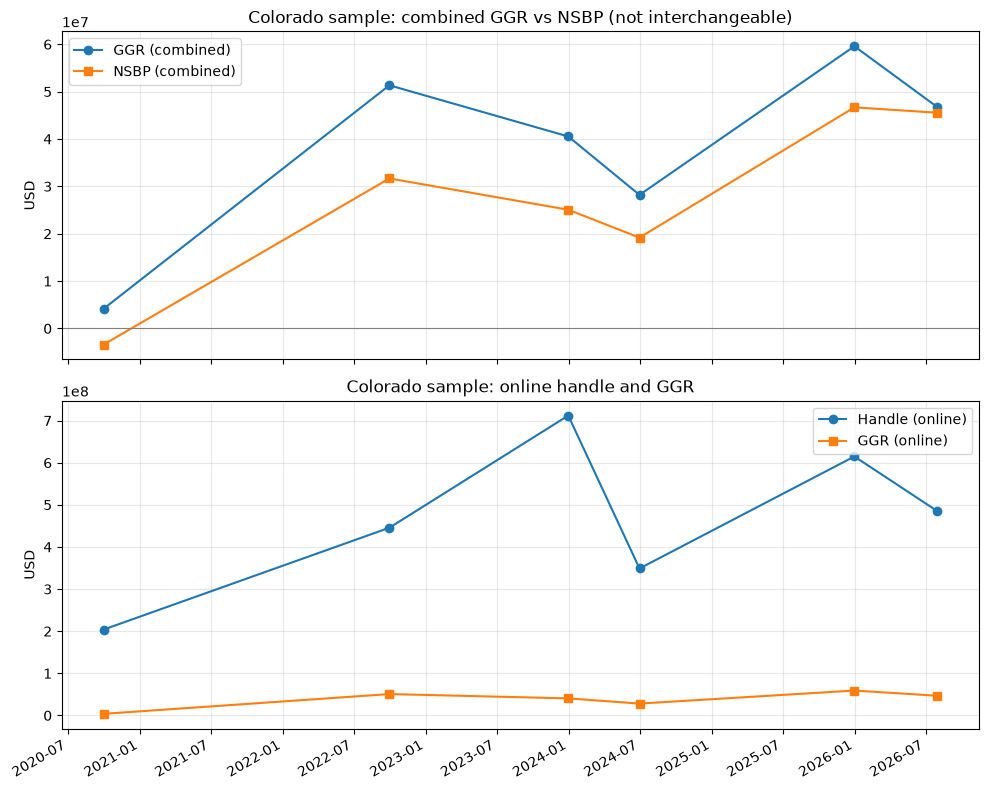

In [10]:
chart = (
    monthly_obs.loc[monthly_obs["channel"].isin(["combined", "online"])]
    .copy()
)
chart["period_end_dt"] = pd.to_datetime(chart["period_end"])

display(
    chart.pivot_table(
        index="period_end_dt",
        columns="channel",
        values=["handle", "gross_gaming_revenue", "net_sports_betting_proceeds"],
        aggfunc="first",
    ).sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

combined = chart.loc[chart["channel"] == "combined"].sort_values("period_end_dt")
axes[0].plot(
    combined["period_end_dt"],
    combined["gross_gaming_revenue"],
    marker="o",
    label="GGR (combined)",
)
axes[0].plot(
    combined["period_end_dt"],
    combined["net_sports_betting_proceeds"],
    marker="s",
    label="NSBP (combined)",
)
axes[0].axhline(0, color="0.5", linewidth=0.8)
axes[0].set_ylabel("USD")
axes[0].set_title("Colorado sample: combined GGR vs NSBP (not interchangeable)")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

online = chart.loc[chart["channel"] == "online"].sort_values("period_end_dt")
axes[1].plot(
    online["period_end_dt"],
    online["handle"],
    marker="o",
    label="Handle (online)",
)
axes[1].plot(
    online["period_end_dt"],
    online["gross_gaming_revenue"],
    marker="s",
    label="GGR (online)",
)
axes[1].set_ylabel("USD")
axes[1].set_title("Colorado sample: online handle and GGR")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 12. Supporting HB 21-1292 city report (optional cross-check)

**What.** Download the July 2026 HB 21-1292 PDF and compare its statewide On-Site/Internet NSBP and tax totals to the July 2026 Proceeds summary.

**Why.** Confirms that the companion series is city-level NSBP/tax, not handle/GGR, and that online/retail NSBP totals can cross-check the main report.

**Assumptions.** HB labels On-Site ≈ Retail and Internet ≈ Online. City rows can be aggregated under HB 21-1292 rules; do not invent operators from cities.

**Inspect.** Parsed HB statewide line versus Proceeds July 2026 retail/online/total NSBP and tax.


In [11]:
hb_label = "July 2026 HB 1292 Monthly Sports Betting Proceeds"
hb_url = inventory.loc[inventory["label"] == hb_label, "url"]
if hb_url.empty:
    raise RuntimeError("July 2026 HB 1292 report not found on landing page")
hb_url = hb_url.iloc[0]
hb_retrieved = utc_now()
hb_response = http_get(hb_url, headers=BROWSER_HEADERS)
hb_path = save_raw_bytes(
    ROOT,
    "CO",
    hb_response.content,
    "HB1292_" + Path(unquote(urlparse(hb_url).path)).name,
    retrieved_at=hb_retrieved,
)
with pdfplumber.open(hb_path) as pdf:
    hb_text = "\n".join((page.extract_text() or "") for page in pdf.pages)

print("HB URL:", hb_url)
print("HB retrieved_at_utc:", hb_retrieved.isoformat().replace("+00:00", "Z"))
print("HB relative path:", hb_path.relative_to(ROOT))
print("HB SHA-256:", sha256_file(hb_path))
print(hb_text[:1200])

# Statewide line on HB report
statewide_line = next(
    (line for line in hb_text.splitlines() if line.strip().startswith("Statewide")),
    None,
)
print("Statewide line:", statewide_line)
hb_vals = [parse_money(tok) for tok in re.findall(MONEY_TOKEN, statewide_line or "")]
hb_vals = [v for v in hb_vals if v is not None]
# Expected geometry: On-Site NSBP, Internet NSBP, Total NSBP, On-Site Tax, Internet Tax, Total Tax
hb_compare = pd.DataFrame(
    [
        {
            "metric": "nsbp_retail_onsite",
            "hb21_1292": None if len(hb_vals) < 1 else hb_vals[0],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "nsbp_retail"].iloc[0],
        },
        {
            "metric": "nsbp_online_internet",
            "hb21_1292": None if len(hb_vals) < 2 else hb_vals[1],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "nsbp_online"].iloc[0],
        },
        {
            "metric": "nsbp_total",
            "hb21_1292": None if len(hb_vals) < 3 else hb_vals[2],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "nsbp_total"].iloc[0],
        },
        {
            "metric": "tax_retail_onsite",
            "hb21_1292": None if len(hb_vals) < 4 else hb_vals[3],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "tax_retail"].iloc[0],
        },
        {
            "metric": "tax_online_internet",
            "hb21_1292": None if len(hb_vals) < 5 else hb_vals[4],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "tax_online"].iloc[0],
        },
        {
            "metric": "tax_total",
            "hb21_1292": None if len(hb_vals) < 6 else hb_vals[5],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "tax_total"].iloc[0],
        },
    ]
)
hb_compare["abs_diff"] = (hb_compare["hb21_1292"] - hb_compare["proceeds_pdf"]).abs()
hb_compare["within_native_tol"] = hb_compare.apply(
    lambda r: money_close(r["hb21_1292"], r["proceeds_pdf"], MONEY_TOL_NATIVE),
    axis=1,
)
display(hb_compare)
print(
    "HB vs Proceeds mismatches at $0.01 native tolerance:",
    int((~hb_compare["within_native_tol"]).sum()),
)


HB URL: https://sbg.colorado.gov/sites/sbg/files/documents/HB%2021-1292%20Report%20July%202026.pdf
HB retrieved_at_utc: 2026-09-05T00:18:22.401974Z
HB relative path: data/raw/CO/2026-09-05/ba5c8c12cae289980ac6a03e2c4b580428bb1b9e2e2e93e005689f0376765910_HB1292_HB_21-1292_Report_July_2026.pdf
HB SHA-256: ba5c8c12cae289980ac6a03e2c4b580428bb1b9e2e2e93e005689f0376765910
Colorado - Division of Gaming
Monthly Sports Betting Proceeds
CURR TOT AMT NSBP TAXES
07/31/26 On-Site Internet Total On-Site Internet Total
Black Hawk $36,842.90 $30,440,405.09 $30,477,247.99 $9,199.39 $3,047,442.83 $3,056,642.22
Central City * $0.00 $0.00 $0.00 $0.00 $0.00 $0.00
Cripple Creek* $0.00 $15,062,464.86 $15,062,464.86 $0.00 $1,506,246.49 $1,506,246.49
Statewide $36,842.90 $45,502,869.95 $45,539,712.85 $9,199.39 $4,553,689.32 $4,562,888.71
Colorado - Division of Gaming
Annual Sports Betting Proceeds
0 0
07/01/2026 - CURR TOT AMT NSBP TAXES 0 0
07/31/2026 On-Site Internet Total On-Site Internet Total
Black Hawk 

,metric,hb21_1292,proceeds_pdf,abs_diff,within_native_tol
0,nsbp_retail_onsite,36842.90,36842.91,0.01,True
1,nsbp_online_internet,45502869.95,45502869.94,0.01,True
2,nsbp_total,45539712.85,45539712.85,0.00,True
3,tax_retail_onsite,9199.39,9199.39,0.00,True
4,tax_online_internet,4553689.32,4553689.32,0.00,True
5,tax_total,4562888.71,4562888.71,0.00,True


HB vs Proceeds mismatches at $0.01 native tolerance: 0


## 13. Final validation and proposed minimal collector

The next cells restate gates, summarize exact reconciliations, and give an implementation-review recommendation **without** changing shared modules.


In [12]:
validation = []

# Gate: sample size / span / latest month
validation.append(
    (
        "sample_span",
        span_years >= 2 and manifest["period"].iloc[0] == "2026-07",
        f"span_years={span_years}, latest={manifest['period'].iloc[0]}",
    )
)

# Gate: GGR identity where handle/payouts present
ggr_ok = reconciliation.loc[
    reconciliation["ggr_reconcile"] != "missing_inputs", "ggr_reconcile"
].eq("ok").all()
validation.append(("handle_minus_payouts_eq_ggr", bool(ggr_ok), "see reconciliation table"))

# Gate: channel additivity for metrics that parsed completely
add_ok = additivity.loc[additivity["status"] != "missing_inputs", "status"].eq("ok").all()
validation.append(("retail_plus_online_eq_combined", bool(add_ok), "see additivity table"))

# Gate: NSBP not written into gross_revenue in the proposal
both_present = proposed_df["gross_revenue"].notna() & proposed_df["net_proceeds"].notna()
distinct_when_present = (
    proposed_df.loc[both_present, "gross_revenue"]
    != proposed_df.loc[both_present, "net_proceeds"]
).all()
validation.append(
    (
        "nsbp_not_labeled_as_ggr",
        bool(both_present.any()) and bool(distinct_when_present),
        "proposed mapping keeps GGR and NSBP in separate columns",
    )
)

# Gate: no database created
validation.append(
    ("no_sqlite_substitute", not DATABASE_PATH.exists(), str(DATABASE_PATH))
)

# Gate: only prototype rows; raw files under ignored data/raw/CO
validation.append(
    (
        "raw_paths_under_data_raw_CO",
        all(str(p).startswith("data/raw/CO/") for p in manifest["relative_path"]),
        "manifest relative_path prefix check",
    )
)

validation_df = pd.DataFrame(validation, columns=["gate", "passed", "detail"])
display(validation_df)
assert validation_df["passed"].all()

print("Exact reconciliation highlights:")
display(
    reconciliation.loc[
        reconciliation["channel"] == "combined",
        [
            "period",
            "reported_ggr",
            "derived_handle_minus_payouts",
            "ggr_diff",
            "ggr_reconcile",
            "nsbp",
            "tax",
            "tax_over_nsbp",
        ],
    ]
)


,gate,passed,detail
0,sample_span,True,"span_years=6, latest=2026-07"
1,handle_minus_payouts_eq_ggr,True,see reconciliation table
2,retail_plus_online_eq_combined,True,see additivity table
3,nsbp_not_labeled_as_ggr,True,proposed mapping keeps GGR and NSBP in separat...
4,no_sqlite_substitute,True,/workspace/data/gaming.sqlite
5,raw_paths_under_data_raw_CO,True,manifest relative_path prefix check


Exact reconciliation highlights:


,period,reported_ggr,derived_handle_minus_payouts,ggr_diff,ggr_reconcile,nsbp,tax,tax_over_nsbp
2,2026-07,46732908.44,46732908.44,0.0,ok,45539712.85,4562888.71,0.100196
5,2025-12,59583229.39,59583229.39,0.0,ok,46685590.94,4631754.34,0.099212
8,2024-06,28196297.25,28196297.25,0.0,ok,19171641.15,1816861.12,0.094768
11,2023-12,40537499.14,40537499.14,0.0,ok,25068032.86,3682334.79,0.146894
14,2022-09,51339659.25,51339659.25,0.0,ok,31670834.25,2989342.47,0.094388
17,2020-09,4166334.21,4166334.21,0.0,ok,-3394190.44,69771.66,-0.020556


### Findings

- Official Colorado sportsbook financials are published monthly as Sports Betting Proceeds PDFs on `https://sbg.colorado.gov/sports-betting-monthly-reports`, with a parallel HB 21-1292 city NSBP/tax series.
- Archive coverage on the landing page runs from May 2020 labels through the latest completed month (July 2026 at retrieval). May/June 2020 PDF URLs returned HTTP 404 in this research. Many 2023–early-2026 files lack a text layer.
- Sampled months: 2020-09, 2022-09, 2023-12, 2024-06, 2025-12, 2026-07.
- Native metrics on the Proceeds PDF: handle (Total Wagers), payouts, GGR, NSBP, tax, win%. Promotions are definitional inputs to NSBP but not a printed statewide column.
- Granularity: statewide Retail / Online / Total, plus sport mix. Not operator/brand. HB 21-1292 adds city On-Site/Internet NSBP and tax.
- Handle − payouts equals reported GGR on every sampled channel-row where both sides parsed, within the a-priori tolerances.
- Retail + online equals combined for parsed handle/payouts/GGR/NSBP/tax rows in the sample.
- Aggregate tax / NSBP is **not** reliably 10% at channel totals (retail especially; also negative-NSBP months). Do not use statewide tax ≈ 0.1 × NSBP as a hard collector gate without operator-level detail.
- July 2026 HB statewide NSBP/tax matches the Proceeds summary within $0.01 (cent-level rounding on one online NSBP field may appear).

### Validated assumptions

- PDF footnote GGR = Gross Wagers − Payments to Players.
- Online and retail are published separately; combined is an official total.
- NSBP is a distinct native measure from GGR.
- Negative NSBP can occur and must be preserved (September 2020 online/total).

### Uncertain assumptions / unresolved issues

- Exact promotion and federal-excise dollar amounts are not printed statewide on the Proceeds summary.
- Why statewide tax/NSBP diverges from 10% on several channel-months (operator floors, true-ups, OCR risk on image months, or other adjustments).
- Full text-layer availability map for every historical month (only probed, not exhaustively downloaded).
- Broken May/June 2020 URLs: launch-month recoverability unknown.
- Whether `channel='retail'` should be added to storage `ALLOWED_CHANNELS` or retail should be stored only as supporting reconciliation outside online eligibility views.
- Unknown precise publication/revision timestamps.

### Historical availability versus sampled coverage

- Landing page lists a near-continuous monthly Proceeds series from 2020 through July 2026 plus HB companions and a few special PDFs.
- This notebook sampled six months only. Sample validation does **not** prove full-history readiness.

### Reported versus derived field mapping (proposed)

| Native measure | Existing field | Notes |
| --- | --- | --- |
| Total Wagers | `handle` | monthly, by channel |
| Payments to Players | (not stored) | use for GGR reconcile only unless schema expands |
| Gross Gaming Revenue (GGR) | `gross_revenue` | never store NSBP here |
| Net Sports Betting Proceeds | `net_proceeds` | never relabel as GGR |
| Total Taxes | `tax` | preserve; do not back into NSBP |
| Win % | (diagnostic) | should track GGR/handle |
| Promotions / free bets | (not published statewide) | leave null; do not invent |
| Sport rows | out of scope for minimal collector | optional later |
| HB city NSBP/tax | optional secondary series | not operator detail |

### Minimal proposed collector (future work; not implemented here)

1. Crawl the monthly Proceeds landing page; retain immutable hashed PDFs under `data/raw/CO/<date>/`.
2. Detect native text vs OCR-needed; parse Retail/Online/Total summary + sport Total handle/payouts.
3. Reconcile handle − payouts to GGR and retail + online to Total using fixed tolerances.
4. Emit `official_statewide_total` rows for `channel=online` and `channel=combined` into existing columns; decide retail-channel policy separately.
5. Record provenance URL, relative path, SHA-256, retrieval UTC; leave publication time null when unknown.
6. Optionally cross-check NSBP/tax to HB 21-1292 statewide lines.
7. Focused future tests: one native-text fixture, one OCR fixture, September 2020 negative NSBP, July 2026 false-parentheses case, additivity, and “do not map NSBP to gross_revenue”.

### Recommendation

**Ready for implementation review** for an online + combined statewide collector prototype based on the monthly Proceeds PDFs, **with explicit follow-ups** for OCR-regime coverage, retail-channel storage policy, launch-month 404s, and tax-ratio behavior.

Not claimed: full-history production readiness, operator-level detail, or shared metric-contract changes.
